In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

from scipy.optimize import curve_fit

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [5]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [11]:
logks = np.arange(-1.5,2.5,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
print(np.log10(rho0))
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=0.5)

14.701876554946962


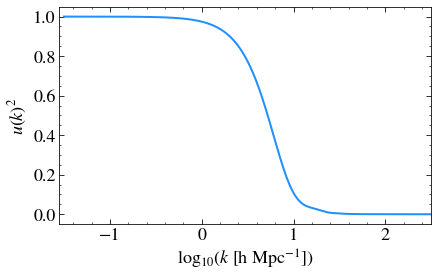

In [14]:

plt.plot(logks, uk_numerical**2, label="NFW ($c=137, r_{\mathrm{vir}}=0.5, r_{\mathrm{max}}=$1.06 cMpc/h)",  c="DodgerBlue")


#plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylabel("$u(k)^2$")
plt.xlim(-1.55,2.5)

# ax = plt.gca()
# ax.annotate(f"logM13-13.1", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")


plt.savefig("../figures/nfw_cartoon.pdf", format="pdf", bbox_inches="tight")